<a href="https://colab.research.google.com/github/r021n/simple-machine-learing/blob/main/Handwritten_Digit_Classification_(MNIST).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FASE 1

## Import library utama

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits

## Memuat dataset digits

In [2]:
digits = load_digits()

## Melihat komponen yang ada di dalam dataset

In [3]:
print(digits.keys())

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


## Melihat jumlah sampel dan bentuk data

In [4]:
print("Shape data:", digits.data.shape)
print("Shape images:", digits.images.shape)
print("Shape target:", digits.target.shape)

Shape data: (1797, 64)
Shape images: (1797, 8, 8)
Shape target: (1797,)


## Memahami satu sampel data

In [5]:
print("Contoh fitur sampel pertama:\n", digits.data[0])
print("Label sampel pertama:", digits.target[0])
print("Bentuk gambar sampel pertama:", digits.images[0].shape)

Contoh fitur sampel pertama:
 [ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
Label sampel pertama: 0
Bentuk gambar sampel pertama: (8, 8)


## Menampilkan deskripsi dataset

In [6]:
print(digits.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

## Melihat label unik pada dataset

In [7]:
print("Label unik:", np.unique(digits.target))

Label unik: [0 1 2 3 4 5 6 7 8 9]


## Menampilkan satu gambar digit beserta labelnya

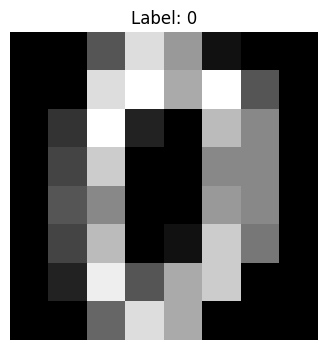

In [8]:
plt.figure(figsize=(4, 4))
plt.imshow(digits.images[0], cmap='gray')
plt.title(f"Label: {digits.target[0]}")
plt.axis("off")
plt.show()

## Menampilkan beberapa contoh gambar digit

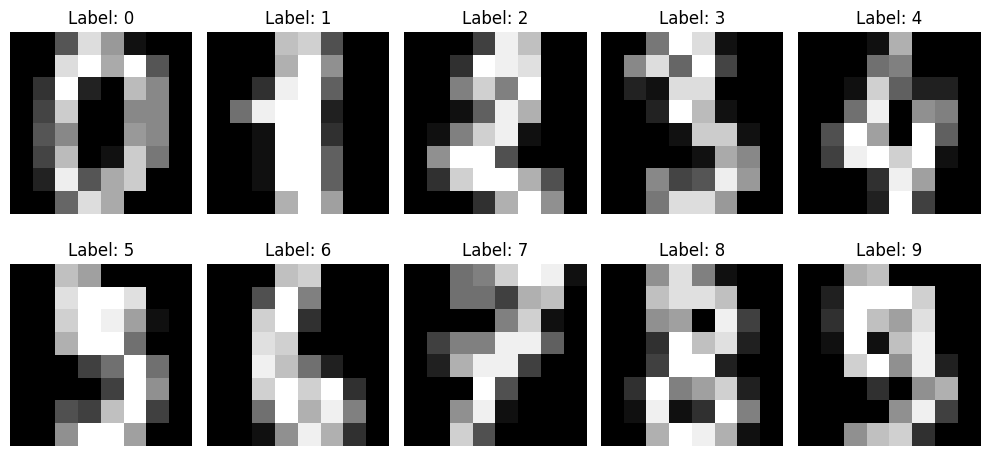

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
  ax.imshow(digits.images[i], cmap="gray")
  ax.set_title(f"Label: {digits.target[i]}")
  ax.axis("off")

plt.tight_layout()
plt.show()

## Menyimpulkan input, output, dan tujuan project secara kode

In [10]:
print("Input model  : fitur numerik dari gambar digit")
print("Output model : label angka 0 sampai 9")
print("Tujuan       : memprediksi digit yang benar dari gambar tulisan tangan")

Input model  : fitur numerik dari gambar digit
Output model : label angka 0 sampai 9
Tujuan       : memprediksi digit yang benar dari gambar tulisan tangan


# FASE 2

## Melihat distribusi label

In [11]:
unique_labels, label_counts = np.unique(digits.target, return_counts=True)

print("Label unik:", unique_labels)
print("Jumlah tiap label:", label_counts)

for label, count in zip(unique_labels, label_counts):
  print(f"Digit {label}:{count} sampel")

Label unik: [0 1 2 3 4 5 6 7 8 9]
Jumlah tiap label: [178 182 177 183 181 182 181 179 174 180]
Digit 0:178 sampel
Digit 1:182 sampel
Digit 2:177 sampel
Digit 3:183 sampel
Digit 4:181 sampel
Digit 5:182 sampel
Digit 6:181 sampel
Digit 7:179 sampel
Digit 8:174 sampel
Digit 9:180 sampel


## Visualisasi distribusi label

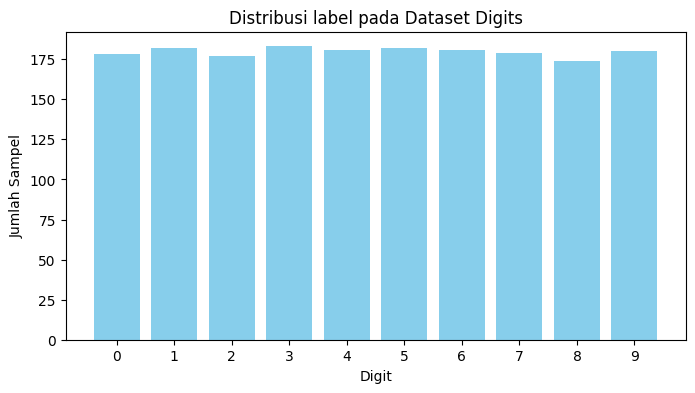

In [12]:
plt.figure(figsize=(8, 4))
plt.bar(unique_labels, label_counts, color="skyblue")
plt.xlabel("Digit")
plt.ylabel("Jumlah Sampel")
plt.title("Distribusi label pada Dataset Digits")
plt.xticks(unique_labels)
plt.show()

## Memahami ukuran gambar dan rentang nilai piksel

In [13]:
print("Shape images:", digits.images.shape)
print("Ukuran satu gambar:", digits.images[0].shape)
print("Nilai piksel minimum:", digits.images.min())
print("Nilai pixel maksimum:", digits.images.max())

Shape images: (1797, 8, 8)
Ukuran satu gambar: (8, 8)
Nilai piksel minimum: 0.0
Nilai pixel maksimum: 16.0


## Melihat contoh nilai piksel dari satu gambar

In [14]:
print("Nilai piksel gambar pertama:\n")
print(digits.images[0])

Nilai piksel gambar pertama:

[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


## Menetapkan fitur dan target

In [15]:
X = digits.data
y = digits.target

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (1797, 64)
Shape y: (1797,)


## Membagi data menjadi data latih dan data uji

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test :", y_test.shape)

Shape X_train: (1437, 64)
Shape X_test : (360, 64)
Shape y_train: (1437,)
Shape y_test : (360,)


## Memeriksa distribusi label setelah split

In [17]:
train_labels, train_counts = np.unique(y_train, return_counts=True)
test_labels, test_counts = np.unique(y_test, return_counts=True)

print("Distribusi label pada data latih:")
for label, count in zip(train_labels, train_counts):
  print(f"Digit {label}: {count} sampel")

print("\nDistribusi label pada data uji:")
for label, count in zip(test_labels, test_counts):
  print(f"Digit {label}: {count} sampel")

Distribusi label pada data latih:
Digit 0: 142 sampel
Digit 1: 146 sampel
Digit 2: 142 sampel
Digit 3: 146 sampel
Digit 4: 145 sampel
Digit 5: 145 sampel
Digit 6: 145 sampel
Digit 7: 143 sampel
Digit 8: 139 sampel
Digit 9: 144 sampel

Distribusi label pada data uji:
Digit 0: 36 sampel
Digit 1: 36 sampel
Digit 2: 35 sampel
Digit 3: 37 sampel
Digit 4: 36 sampel
Digit 5: 37 sampel
Digit 6: 36 sampel
Digit 7: 36 sampel
Digit 8: 35 sampel
Digit 9: 36 sampel


## Melakukan standardisasi fitur dengan StandardScaler

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape X_train_scaled:", X_train_scaled.shape)
print("Shape X_test_scaled :", X_test_scaled.shape)

Shape X_train_scaled: (1437, 64)
Shape X_test_scaled : (360, 64)


## Membandingkan fitur sebelum dan sesudah scaling

In [19]:
print("Sebelum scaling:")
print("Mean fitur pertama:", X_train[:, 0].mean())
print("Std fitur pertama :", X_train[:, 0].std())

print("\nSesudah scaling:")
print("Mean fitur pertama:", X_train_scaled[:, 0].mean())
print("Std fitur pertama :", X_train_scaled[:, 0].std())

Sebelum scaling:
Mean fitur pertama: 0.0
Std fitur pertama : 0.0

Sesudah scaling:
Mean fitur pertama: 0.0
Std fitur pertama : 0.0


## Ringkasan data siap untuk modeling

In [20]:
print("Data siap untuk modeling:")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled : {X_test_scaled.shape}")
print(f"y_train       : {y_train.shape}")
print(f"y_test        : {y_test.shape}")

Data siap untuk modeling:
X_train_scaled: (1437, 64)
X_test_scaled : (360, 64)
y_train       : (1437,)
y_test        : (360,)


# FASE 3

## Import library untuk modeling dan evaluasi

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Membuat pipeline scaling + SVM

In [22]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

## Melatih model pada data latih

In [23]:
svm_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC())])

## Melakukan prediksi pada data uji

In [24]:
y_pred = svm_pipeline.predict(X_test)

print("5 prediksi pertama:", y_pred[:5])
print("5 label asli      :", y_test[:5])

5 prediksi pertama: [5 2 8 1 7]
5 label asli      : [5 2 8 1 7]


## Menghitung akurasi model

In [25]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.975


## Menampilkan confusion matrix

In [26]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[36  0  0  0  0  0  0  0  0  0]
 [ 0 35  0  0  1  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 35  0  0  1  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 36  0  0  0]
 [ 0  0  0  0  0  1  0 35  0  0]
 [ 0  2  0  0  1  0  0  0 32  0]
 [ 0  0  0  0  0  0  1  2  0 33]]


## Menampilkan classification report

In [27]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.95      0.97      0.96        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.95      0.97      0.96        36
           5       0.97      1.00      0.99        37
           6       0.97      1.00      0.99        36
           7       0.92      0.97      0.95        36
           8       1.00      0.91      0.96        35
           9       1.00      0.92      0.96        36

    accuracy                           0.97       360
   macro avg       0.98      0.97      0.97       360
weighted avg       0.98      0.97      0.97       360



## Menampilkan beberapa hasil prediksi pada gambar

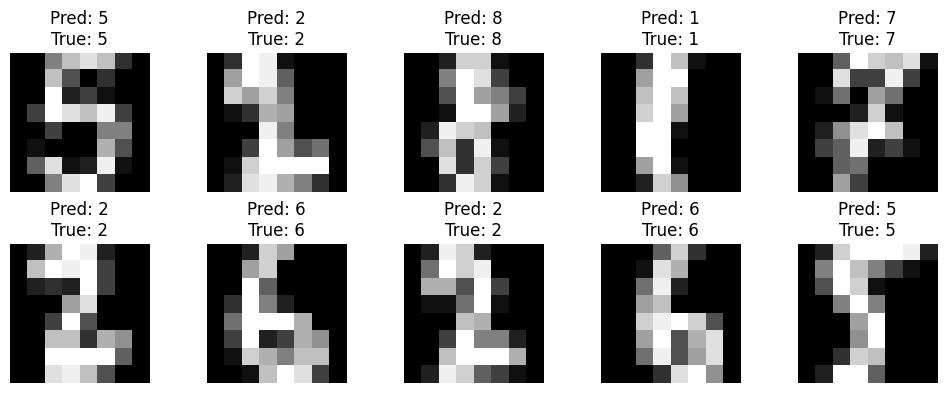

In [30]:
plt.figure(figsize=(10, 4))

for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(X_test[i].reshape(8, 8), cmap='gray')
  plt.title(f"Pred: {y_pred[i]}\nTrue: {y_test[i]}")
  plt.axis("off")

plt.tight_layout()
plt.show()

## Menampilkan contoh prediksi yang salah

Jumlah prediksi salah: 9


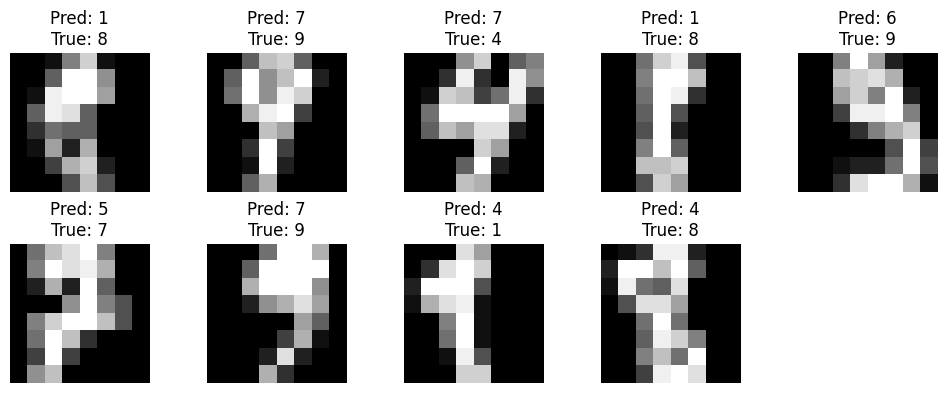

In [32]:
wrong_indices = np.where(y_pred != y_test)[0]

print("Jumlah prediksi salah:", len(wrong_indices))

plt.figure(figsize=(10, 4))

for i, idx in enumerate(wrong_indices[:10]):
  plt.subplot(2, 5, i + 1)
  plt.imshow(X_test[idx].reshape(8, 8), cmap='gray')
  plt.title(f"Pred: {y_pred[idx]}\nTrue: {y_test[idx]}")
  plt.axis("off")

plt.tight_layout()
plt.show()

## Ringkasan baseline model

In [33]:
print("Baseline model selesai dibuat.")
print(f"Akurasi baseline SVM: {accuracy:.4f}")
print("Model ini akan menjadi acuan untuk fase berikutnya.")

Baseline model selesai dibuat.
Akurasi baseline SVM: 0.9750
Model ini akan menjadi acuan untuk fase berikutnya.
